# 02 - Exploratory Data Analysis: Motorcycle Insurance
Explore claim frequency and severity by segment, check relationships between variables, and validate the bonus-malus (no-claims discount) system before any modeling.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/motorcycle_clean.csv")

# frequency/severity need real exposure -> zero-exposure rows would divide by zero
df_exp = df[~df["is_zero_exposure"]].copy()
print(
    f"Full data: {len(df):,} rows | used for frequency/severity: {len(df_exp):,} rows "
    f"({len(df) - len(df_exp):,} zero-exposure rows excluded)"
)

df_exp.head()

Full data: 64,548 rows | used for frequency/severity: 62,474 rows (2,074 zero-exposure rows excluded)


,policy_id,owner_age,gender,zone,vehicle_class,vehicle_age,bonus_class,duration_years,claim_count,claim_cost,is_zero_exposure
0,1,0,Male,1,4,12,1,0.175342,0,0,False
2,3,5,Female,3,3,18,1,0.454795,0,0,False
3,4,5,Female,4,1,25,1,0.172603,0,0,False
4,5,6,Female,2,1,26,1,0.180822,0,0,False
5,6,9,Female,3,3,8,1,0.542466,0,0,False


## 1. Build readable groups

Bucket the continuous variables (`owner_age`, `vehicle_age`) into groups so segment comparisons are easier to read and plot.

In [2]:
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
df_exp["age_group"] = pd.cut(df_exp["owner_age"], bins=age_bins, labels=age_labels, right=False)

veh_bins = [0, 3, 6, 10, 15, 100]
veh_labels = ["0-2", "3-5", "6-9", "10-14", "15+"]
df_exp["vehicle_age_group"] = pd.cut(df_exp["vehicle_age"], bins=veh_bins, labels=veh_labels, right=False)

df_exp[["owner_age", "age_group", "vehicle_age", "vehicle_age_group"]].head()

,owner_age,age_group,vehicle_age,vehicle_age_group
0,0,<25,12,10-14
2,5,<25,18,15+
3,5,<25,25,15+
4,6,<25,26,15+
5,9,<25,8,6-9


## 2. Overall risk baseline

Before comparing segments, establish the overall numbers as a reference line.

In [3]:
total_exposure = df_exp["duration_years"].sum()
total_claims = df_exp["claim_count"].sum()
total_cost = df_exp["claim_cost"].sum()
claims_only = df_exp[df_exp["claim_count"] > 0]

overall_frequency = total_claims / total_exposure
overall_severity = claims_only["claim_cost"].sum() / claims_only["claim_count"].sum()
overall_pure_premium = total_cost / total_exposure

print(f"Total exposure (policy-years): {total_exposure:,.1f}")
print(f"Total claims: {total_claims:,}")
print(f"Overall claim frequency: {overall_frequency:.4f} claims per policy-year")
print(f"Overall average severity (cost per claim): {overall_severity:,.0f}")
print(f"Overall pure premium (cost per policy-year): {overall_pure_premium:,.1f}")

Total exposure (policy-years): 65,236.8
Total claims: 693
Overall claim frequency: 0.0106 claims per policy-year
Overall average severity (cost per claim): 24,446
Overall pure premium (cost per policy-year): 259.7


### "ปี" ในที่นี้คืออะไร (ภาษาไทย)

คำว่า **"policy-year" (ปีกรมธรรม์)** ที่เห็นด้านบน **ไม่ใช่ปีปฏิทิน** — มันคือหน่วยวัด "ระยะเวลาที่กรมธรรม์คุ้มครองจริง" รวมกันทั้งหมด

- กรมธรรม์ 1 อัน ที่คุ้มครองเต็มปี = 1 policy-year
- กรมธรรม์ 1 อัน ที่คุ้มครองแค่ 6 เดือน = 0.5 policy-year
- เอา `duration_years` ของทุกแถว (ทุกกรมธรรม์) มา**บวกรวมกัน** → ได้ total exposure = 65,236.8 policy-years

พูดง่าย ๆ คือ ถ้ามีกรมธรรม์ 3 อัน คุ้มครอง 1 ปี, 0.5 ปี, 0.3 ปี ตามลำดับ → รวมกันได้ 1.8 policy-years (ไม่ใช่ "1.8 ปีปฏิทิน" แต่คือผลรวมของระยะเวลาคุ้มครองทั้งหมด) ใช้ตัวเลขนี้เป็นตัวหารตอนคำนวณ "อัตราการเคลมต่อปี" (frequency) เพื่อให้เทียบกันได้อย่างยุติธรรม ไม่ว่ากรมธรรม์แต่ละอันจะคุ้มครองนานแค่ไหนก็ตาม

## 3. Claim frequency by segment

Frequency = total claims ÷ total exposure (policy-years) **per group** — this is the correct way to compare groups with different amounts of exposure. A plain average of `claim_count` per row would be misleading since policies have very different `duration_years`.

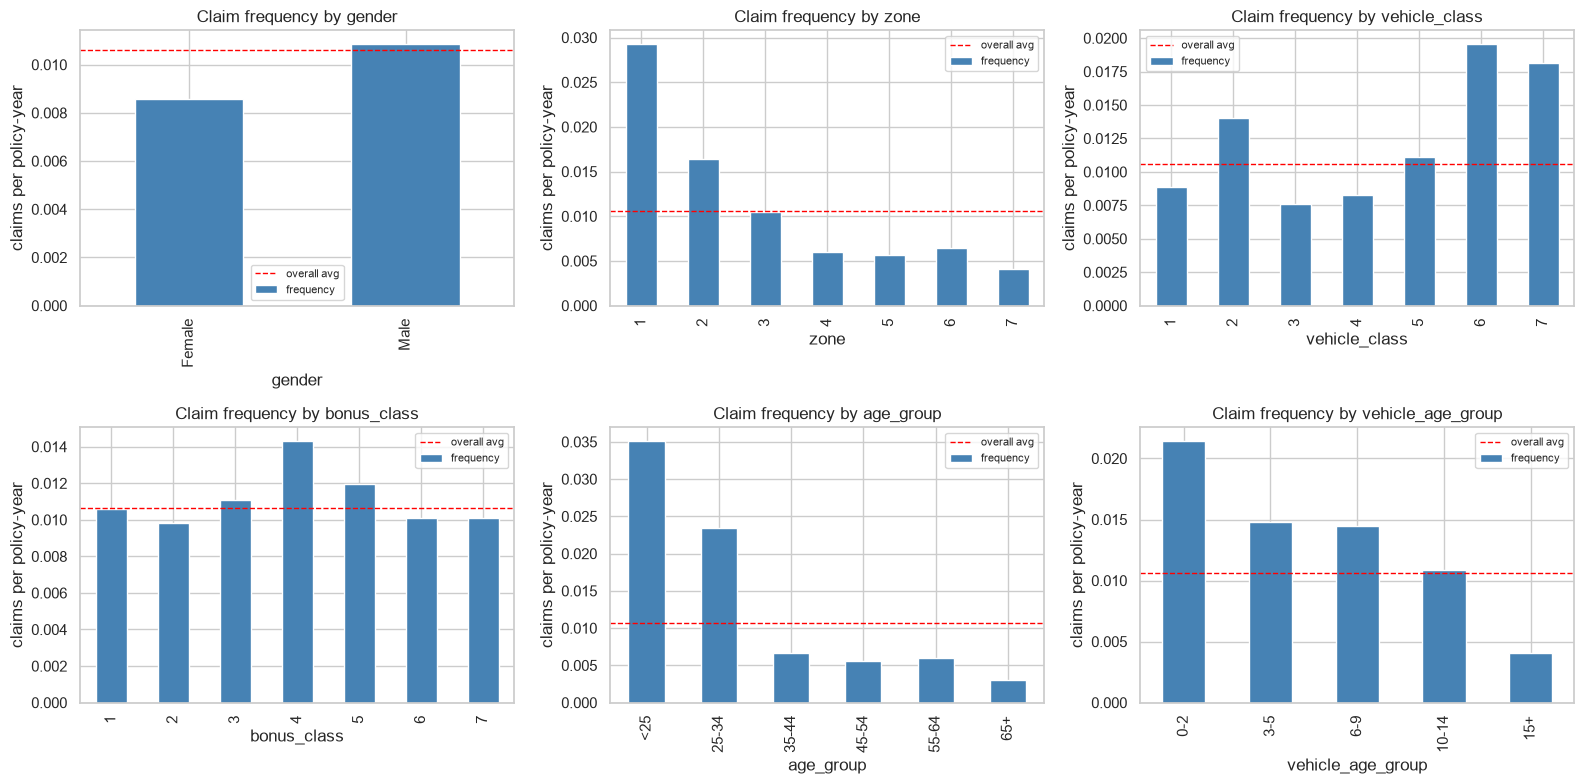

In [4]:
def frequency_by(data, group_col):
    g = data.groupby(group_col, observed=True).agg(
        exposure=("duration_years", "sum"),
        claims=("claim_count", "sum"),
    )
    g["frequency"] = g["claims"] / g["exposure"]
    return g.sort_index()


segment_cols = ["gender", "zone", "vehicle_class", "bonus_class", "age_group", "vehicle_age_group"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, segment_cols):
    freq_table = frequency_by(df_exp, col)
    freq_table["frequency"].plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"Claim frequency by {col}")
    ax.set_ylabel("claims per policy-year")
    ax.axhline(overall_frequency, color="red", linestyle="--", linewidth=1, label="overall avg")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### กราฟชุดนี้ดูอะไร (ภาษาไทย)

กราฟ 6 อันด้านบนคือ "อัตราการเคลมต่อปี" (แกน y) แยกตามแต่ละปัจจัย (เพศ, โซน, คลาสรถ, bonus class, กลุ่มอายุ, กลุ่มอายุรถ) เส้นสีแดงคือค่าเฉลี่ยรวมทั้งหมด (0.0106) เพื่อให้เทียบง่าย ๆ ว่าแท่งไหนสูงกว่า/ต่ำกว่าค่าเฉลี่ย

**สิ่งที่เจอ:** อายุ (โดยเฉพาะกลุ่มต่ำกว่า 25) และโซน 1 คือปัจจัยที่ทำให้อัตราเคลมสูงกว่าค่าเฉลี่ยชัดเจนที่สุด

### Total claims by segment (raw counts, not adjusted for exposure)

Same segments as above, but the y-axis is now the **raw total number of claims** instead of the exposure-adjusted frequency. Sorted from most to least claims. Note: a group can have a high total simply because it has more policies/exposure in it, not necessarily because it's riskier per policy — that's exactly why the frequency chart above (which divides by exposure) is the fairer comparison. This chart is more useful for answering "where do most of our actual claims come from" rather than "which group is riskiest per policy."

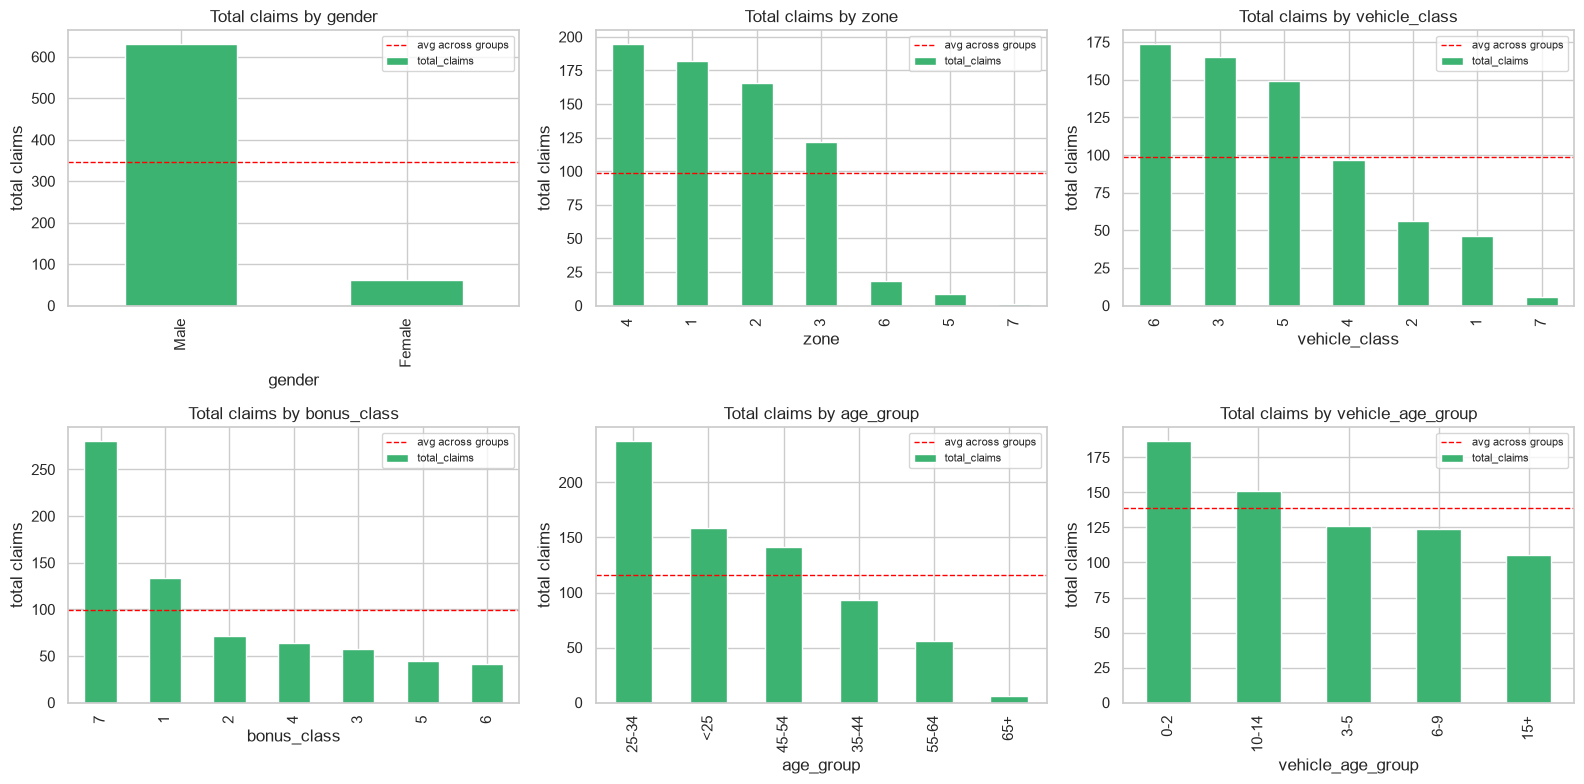

In [6]:
def total_claims_by(data, group_col):
    g = data.groupby(group_col, observed=True).agg(total_claims=("claim_count", "sum"))
    return g.sort_values("total_claims", ascending=False)


fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, segment_cols):
    claims_table = total_claims_by(df_exp, col)
    claims_table["total_claims"].plot(kind="bar", ax=ax, color="mediumseagreen")
    ax.set_title(f"Total claims by {col}")
    ax.set_ylabel("total claims")
    avg_claims = claims_table["total_claims"].mean()
    ax.axhline(avg_claims, color="red", linestyle="--", linewidth=1, label="avg across groups")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### กราฟชุดนี้ดูอะไร (ภาษาไทย)

กราฟชุดนี้เปลี่ยนจาก "อัตราเคลมต่อปี" (frequency) เป็น **"จำนวนเคลมรวมจริง ๆ"** (นับตัวเลขดิบ ไม่หารด้วย exposure) เรียงจากมากไปน้อย เส้นแดงคือค่าเฉลี่ยของแท่งทั้งหมดในกราฟนั้น (ไม่ใช่ค่าคงที่ตัวเดียวกันทุกกราฟเหมือนก่อนหน้า เพราะจำนวนกลุ่มในแต่ละปัจจัยไม่เท่ากัน เช่น เพศมี 2 กลุ่ม แต่โซนมี 7 กลุ่ม)

**สิ่งที่น่าสนใจ (ต่างจากกราฟ frequency ก่อนหน้านี้):**
- **age_group**: กราฟ frequency บอกว่า `<25` เสี่ยงสุด แต่กราฟนี้กลับบอกว่า `25-34` มีจำนวนเคลม*รวม*มากที่สุด เหตุผลคือกลุ่ม `25-34` มีจำนวนกรมธรรม์ (exposure) เยอะกว่ากลุ่ม `<25` มาก ถึงจะเคลม*น้อยกว่าต่อปี* แต่พอมีคนเยอะ ผลรวมเลยมากกว่า
- **bonus_class**: class 7 (สูงสุด) กลับมีจำนวนเคลมรวมมากที่สุด ทั้งที่ frequency ของ class 7 ไม่ได้สูงสุด เพราะคนที่อยู่ class 7 มานาน (ขับดีสะสมมาเรื่อย ๆ) มีจำนวนกรมธรรม์สะสมเยอะกว่ากลุ่มอื่น

**ข้อคิดสำคัญ:** กราฟนี้ตอบคำถาม **"เคลมส่วนใหญ่มาจากกลุ่มไหน"** (มีประโยชน์เวลาวางแผนจัดการเคลม/ทรัพยากร) ส่วนกราฟ frequency ก่อนหน้าตอบคำถาม **"กลุ่มไหนเสี่ยงต่อกรมธรรม์ 1 อันมากที่สุด"** (มีประโยชน์เวลาตั้งราคาเบี้ยประกัน) สองคำถามนี้ไม่เหมือนกัน และคำตอบก็ไม่จำเป็นต้องตรงกัน

## 4. Does the bonus-malus (no-claims discount) system work?

If the system works as intended, frequency should generally go **down** as `bonus_class` goes up (a new driver starts at class 1; each claim-free year moves them up; a claim drops them back 2 classes).

In [7]:
bonus_freq = frequency_by(df_exp, "bonus_class")
print(bonus_freq)

is_monotonic = bonus_freq["frequency"].is_monotonic_decreasing
print(f"\nIs frequency strictly decreasing as bonus_class goes up? {is_monotonic}")

# check if bonus_class is confounded with age (older/more experienced riders reach higher bonus classes)
print("\nAverage owner_age by bonus_class:")
print(df_exp.groupby("bonus_class", observed=True)["owner_age"].mean())

                 exposure  claims  frequency
bonus_class                                 
1            12657.104038     134   0.010587
2             7236.265761      71   0.009812
3             5150.923282      57   0.011066
4             4464.841135      64   0.014334
5             3771.153419      45   0.011933
6             4060.180796      41   0.010098
7            27896.342396     281   0.010073

Is frequency strictly decreasing as bonus_class goes up? False

Average owner_age by bonus_class:
bonus_class
1    39.908303
2    41.059051
3    41.741990
4    42.338321
5    42.209019
6    42.870652
7    45.665667
Name: owner_age, dtype: float64


### ตารางนี้ดูอะไร / What this table shows

**ภาษาไทย:** ตารางด้านบนคือ "อัตราการเคลมต่อปี" เทียบกับ `bonus_class` (1 ถึง 7) — ข้อมูลชุดเดียวกับแผง bonus_class ในกราฟข้อ 3 นั่นเอง แนวคิดของระบบ bonus-malus (ส่วนลดไม่เคลม) คือ ยิ่ง class สูง (ขับดีไม่เคลมมานาน) ควรจะยิ่งเคลมน้อยลง — **ถ้าระบบทำงานได้จริง ตัวเลข frequency ควรจะ "ลดลงเรื่อย ๆ" ตาม class ที่สูงขึ้น**

**สิ่งที่เจอจริง:** ตัวเลข**ไม่ได้ลดลงเรื่อย ๆ** — class 4 กลับมีอัตราเคลมสูงที่สุด (0.014) ไม่ใช่ class 1 ที่เป็นจุดเริ่มต้น ผลตรวจสอบ `is_monotonic_decreasing` ก็ออกมาเป็น **False** ยืนยันว่าไม่ได้ลดลงตามที่คาดไว้

แต่พอเช็คอายุเฉลี่ยของแต่ละ bonus_class กลับพบว่าอายุเฉลี่ยเพิ่มขึ้นตาม class จริง (39.9 → 45.7 ปี) แปลว่า `bonus_class` สะท้อน "อายุ/ประสบการณ์การขับ" มากกว่าจะเป็นตัวชี้วัดความเสี่ยงที่แม่นยำด้วยตัวเอง

---

**English:** The table above shows claim frequency against `bonus_class` (1 to 7) — the same numbers already plotted in the bonus_class panel in section 3. If the no-claims discount system worked as designed, frequency should **decrease steadily** as bonus_class goes up.

**What actually happens:** frequency does **not** decrease cleanly — class 4 has the *highest* frequency (0.014), not class 1 where everyone starts. The `is_monotonic_decreasing` check confirms this with **False**.

However, average `owner_age` does rise steadily with `bonus_class` (39.9 → 45.7 years), showing that bonus class mostly reflects driving tenure/experience rather than being an accurate risk signal on its own.

## 5. Claim severity by segment

Severity = average cost **per claim**, so this only uses policies where `claim_count > 0` (only 693 claims in total — some segments below will have very few claims, so treat small-sample severities with caution).

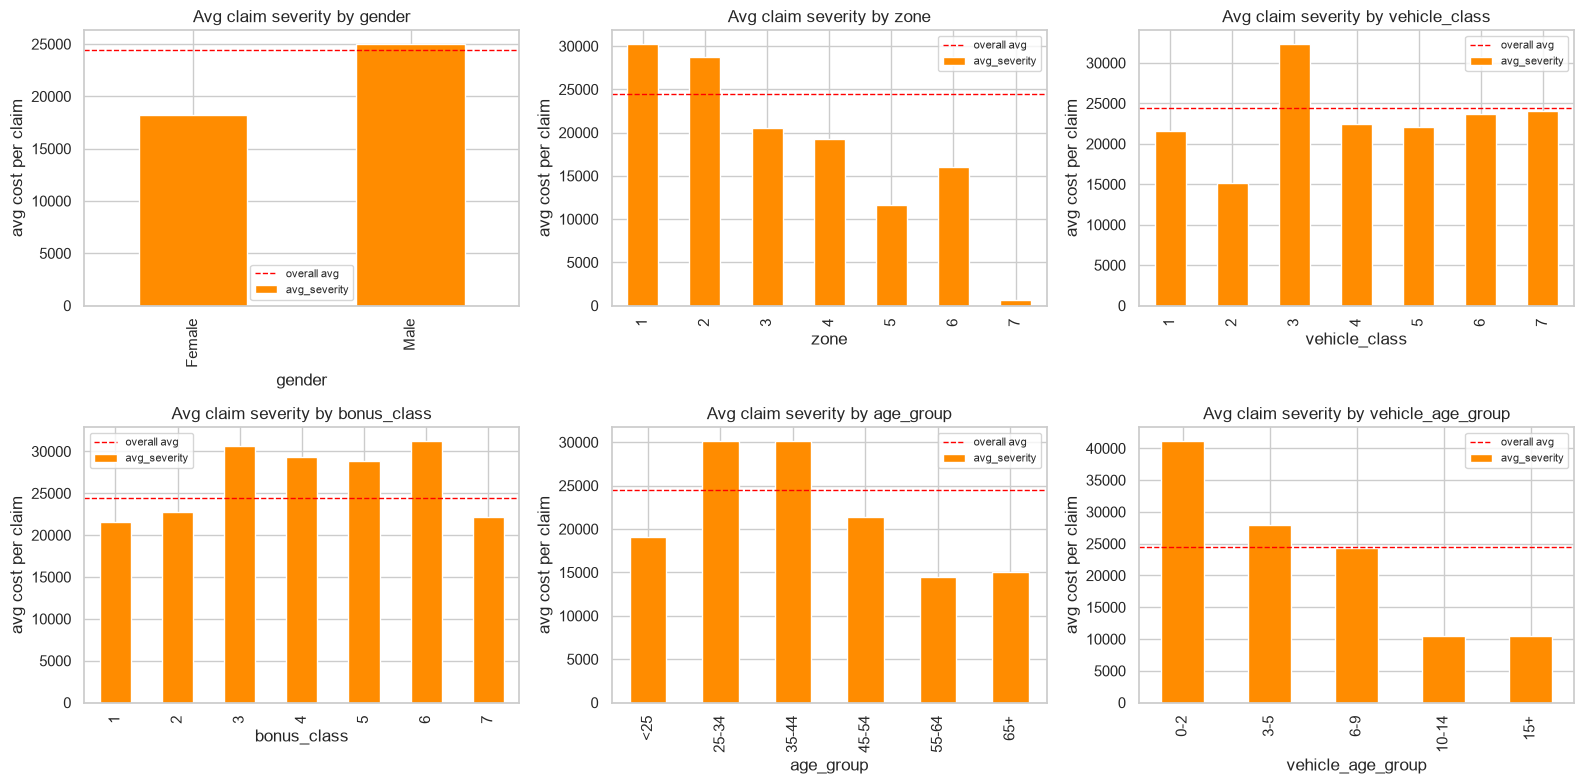

In [6]:
def severity_by(data, group_col):
    claims = data[data["claim_count"] > 0]
    g = claims.groupby(group_col, observed=True).agg(
        n_claims=("claim_count", "sum"),
        total_cost=("claim_cost", "sum"),
    )
    g["avg_severity"] = g["total_cost"] / g["n_claims"]
    return g.sort_index()


fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, segment_cols):
    sev_table = severity_by(df_exp, col)
    sev_table["avg_severity"].plot(kind="bar", ax=ax, color="darkorange")
    ax.set_title(f"Avg claim severity by {col}")
    ax.set_ylabel("avg cost per claim")
    ax.axhline(overall_severity, color="red", linestyle="--", linewidth=1, label="overall avg")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### กราฟชุดนี้ดูอะไร (ภาษาไทย)

กราฟชุดนี้คล้ายกับชุดก่อนหน้า แต่เปลี่ยนจาก "เคลมบ่อยแค่ไหน" เป็น **"เคลมแต่ละครั้งแพงแค่ไหน"** (แกน y = ค่าเสียหายเฉลี่ยต่อครั้งเคลม) ใช้ข้อมูลเฉพาะแถวที่เคยเคลมจริงเท่านั้น (693 ครั้ง)

**สิ่งที่น่าสนใจ:** รูปแบบไม่เหมือนกราฟความถี่เป๊ะ ๆ เช่น กลุ่มอายุ 25-44 กลับมีค่าเสียหายเฉลี่ยสูงสุด ทั้งที่กลุ่มอายุต่ำกว่า 25 เคลม*บ่อย*กว่า — นี่คือเหตุผลที่ต้องแยกโมเดล "ความถี่" กับ "ความรุนแรง" ออกจากกัน ไม่รวมเป็นโมเดลเดียว

In [7]:
# check sample size behind each severity number -- some segments have very few claims
print("Severity by zone, with claim count (n_claims) for reliability check:")
print(severity_by(df_exp, "zone"))

Severity by zone, with claim count (n_claims) for reliability check:
      n_claims  total_cost  avg_severity
zone                                    
1          182     5513403  30293.423077
2          166     4779266  28790.759036
3          122     2509647  20570.877049
4          195     3745300  19206.666667
5            9      104739  11637.666667
6           18      288045  16002.500000
7            1         650    650.000000


## 6. Distribution of claim cost

Insurance claim costs are almost always right-skewed: most claims are small, a few are very expensive.

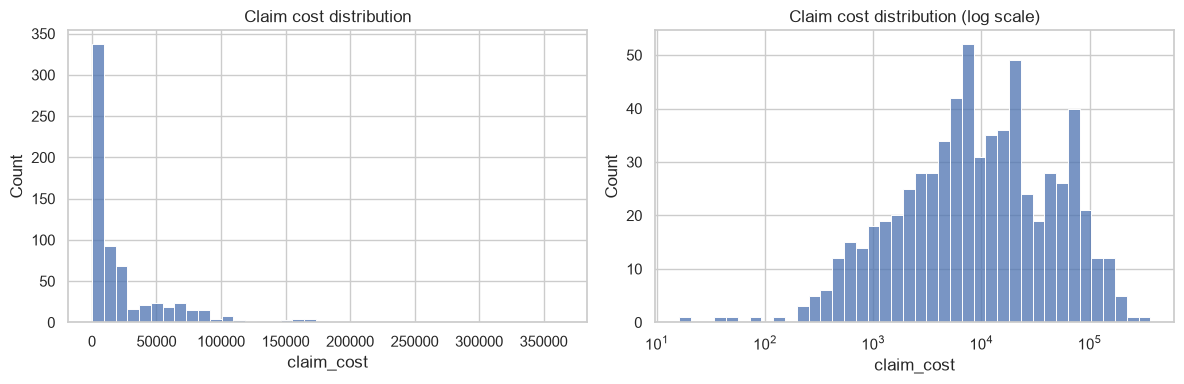

Top 1% most expensive claims (6 claims) = 8.3% of total claim cost
Largest single claim: 365,347
Median claim: 8,920


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(claims_only["claim_cost"], bins=40, ax=axes[0])
axes[0].set_title("Claim cost distribution")

sns.histplot(claims_only["claim_cost"], bins=40, log_scale=True, ax=axes[1])
axes[1].set_title("Claim cost distribution (log scale)")
plt.tight_layout()
plt.show()

sorted_costs = claims_only["claim_cost"].sort_values(ascending=False)
top_1pct_n = max(1, int(len(sorted_costs) * 0.01))
top_1pct_share = sorted_costs.head(top_1pct_n).sum() / sorted_costs.sum()
print(f"Top 1% most expensive claims ({top_1pct_n} claims) = {top_1pct_share:.1%} of total claim cost")
print(f"Largest single claim: {sorted_costs.iloc[0]:,.0f}")
print(f"Median claim: {sorted_costs.median():,.0f}")

### กราฟชุดนี้ดูอะไร (ภาษาไทย)

ฮิสโตแกรม (histogram) 2 อันนี้แสดง "การกระจายตัวของค่าเสียหายต่อครั้งเคลม" — อันซ้ายเป็นสเกลปกติ อันขวาเป็นสเกล log (บีบตัวเลขใหญ่ ๆ ให้ดูง่ายขึ้น)

**สิ่งที่เจอ:** ข้อมูลเบ้ขวาอย่างชัดเจน (right-skewed) คือ เคลมส่วนใหญ่มูลค่าน้อย มีส่วนน้อยที่แพงมาก ๆ — ตัวเลขสำคัญ: ค่ามัธยฐาน (median) อยู่ที่ 8,920 แต่ค่าเฉลี่ย (mean) อยู่ที่ 24,446 (สูงกว่ามาก เพราะถูกดึงขึ้นโดยเคลมแพง ๆ ไม่กี่ครั้ง) และเคลมที่แพงที่สุด 1% (แค่ 6 ครั้ง) รวมกันคิดเป็น 8.3% ของค่าเสียหายทั้งหมด

## 7. Relationships between numeric variables

A quick correlation check across the raw numeric columns (not a substitute for the GLM later, just a sanity check for obvious relationships).

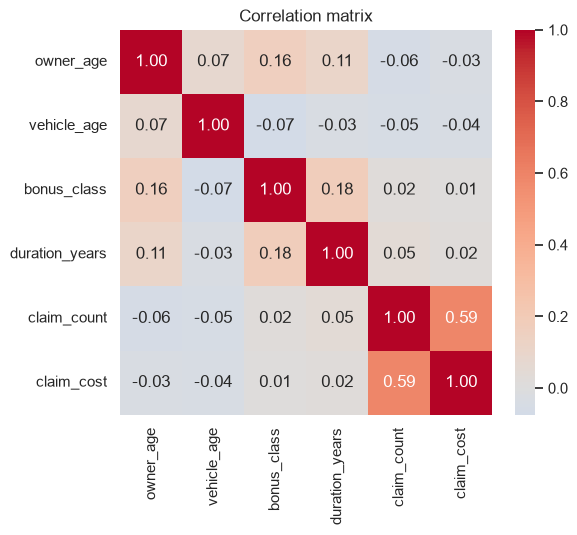

In [9]:
numeric_cols = ["owner_age", "vehicle_age", "bonus_class", "duration_years", "claim_count", "claim_cost"]
corr = df_exp[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

### correlation matrix นี้ดูอะไร (ภาษาไทย)

ตาราง/สีที่เห็นเรียกว่า **correlation matrix** — เป็นการเช็คว่าตัวแปรตัวเลข 2 ตัว "เคลื่อนไหวไปด้วยกัน" มากแค่ไหน ค่าอยู่ระหว่าง -1 ถึง +1:
- ใกล้ **+1** = เพิ่มด้วยกัน (เช่น ตัวหนึ่งขึ้น อีกตัวก็ขึ้นตาม)
- ใกล้ **-1** = สวนทางกัน (ตัวหนึ่งขึ้น อีกตัวลง)
- ใกล้ **0** = แทบไม่มีความสัมพันธ์แบบเส้นตรงต่อกัน

**จุดที่ต้องระวัง (สำคัญมาก):** ค่า correlation ระหว่าง `owner_age` กับ `claim_count` ออกมาต่ำมาก (-0.06) ซึ่ง**ดูเหมือนจะขัดแย้ง**กับที่เจอในกราฟความถี่ก่อนหน้า (อายุมีผลชัดเจนมาก) — แต่จริง ๆ ไม่ขัดแย้งกัน เพราะ correlation แบบนี้วัดความสัมพันธ์แบบ "เส้นตรง" เท่านั้น ในขณะที่ `claim_count` ส่วนใหญ่เป็น 0 แทบทั้งหมด (มีเคลมจริงแค่ 693 จาก 62,474 แถว) ความสัมพันธ์จริงจึงไม่ใช่เส้นตรง ตาราง correlation เลยมองไม่เห็นรูปแบบที่แท้จริง — ตารางแยกกลุ่ม (frequency by segment) ที่ทำไปก่อนหน้านี้เชื่อถือได้มากกว่าสำหรับข้อมูลแบบนี้

Note: the correlations above look weak (e.g. `owner_age` vs `claim_count` is only -0.06), which seems to contradict the strong age pattern seen in section 3. This is expected — plain linear correlation is a poor measure here because `claim_count` is a rare, mostly-zero count and the true relationship is non-linear. The grouped frequency/severity tables above are far more informative for this kind of data than a correlation matrix; this is exactly why insurers use a Poisson/Gamma GLM instead of plain linear correlation.

## 8. Combined risk ranking

Which combination of age group x zone x vehicle class has the highest **pure premium** (expected cost per policy-year)? Only groups with enough exposure are shown, so the ranking isn't driven by a couple of lucky/unlucky policies.

In [10]:
combo = df_exp.groupby(["age_group", "zone", "vehicle_class"], observed=True).agg(
    exposure=("duration_years", "sum"),
    claims=("claim_count", "sum"),
    total_cost=("claim_cost", "sum"),
)
combo = combo[combo["exposure"] >= 50]  # keep only groups with enough data to trust
combo["frequency"] = combo["claims"] / combo["exposure"]
combo["pure_premium"] = combo["total_cost"] / combo["exposure"]

print(f"Groups with at least 50 policy-years of exposure: {len(combo)}")
print(f"Overall pure premium for comparison: {overall_pure_premium:,.1f}")
print("\nTop 10 riskiest combinations (highest pure premium):")
combo.sort_values("pure_premium", ascending=False).head(10)

Groups with at least 50 policy-years of exposure: 154
Overall pure premium for comparison: 259.7

Top 10 riskiest combinations (highest pure premium):


exposure  claims  total_cost  frequency  \
age_group zone vehicle_class                                              
<25       2    6               75.115067       8      345595   0.106503   
25-34     1    6              183.054794      21      788104   0.114720   
<25       1    4               61.238353       7      235049   0.114307   
               3              121.912324      14      256551   0.114837   
25-34     1    3              509.712332      27      969440   0.052971   
               5              345.613694      18      631411   0.052081   
<25       3    5              161.630127       8      289385   0.049496   
          2    4              122.430141       6      217576   0.049008   
25-34     1    4              352.865751      14      620906   0.039675   
          3    2               81.983559       4      133435   0.048790   

                              pure_premium  
age_group zone vehicle_class                
<25       2    6               4600.874549  
25-34     1    6               4305.290142  
<25       1    4               3838.264559  
               3               2104.389381  
25-34     1    3               1901.935541  
               5               1826.927031  
<25       3    5               1790.414976  
          2    4               1777.144078  
25-34     1    4               1759.609705  
          3    2               1627.582428

### ตารางนี้ดูอะไร (ภาษาไทย)

ตารางนี้เอา 3 ปัจจัยที่แรงที่สุด (กลุ่มอายุ x โซน x คลาสรถ) มา**รวมกัน** แล้วคำนวณ "pure premium" (ต้นทุนความเสี่ยงต่อปี) ของแต่ละชุดค่าผสม — กรองเอาเฉพาะชุดที่มีข้อมูลมากพอ (exposure ≥ 50 policy-years) เพื่อไม่ให้อันดับถูกกำหนดโดยกรมธรรม์แค่ 2-3 อันที่บังเอิญโชคร้าย

**สิ่งที่เจอ:** ชุดที่เสี่ยงที่สุดคือ อายุต่ำกว่า 25 + โซน 2 + คลาสรถ 6 ซึ่งมี pure premium สูงถึง **17.7 เท่า** ของค่าเฉลี่ยรวม — นี่คือ "หลักฐานตัวเลขจริง" ที่จะเอาไปใช้ตอนสร้างโมเดลราคาในขั้นตอนถัดไป

## Summary of key findings

**Baseline:** overall claim frequency is 0.0106 claims per policy-year (~1 in 94 policy-years), average severity per claim is 24,446, giving an overall pure premium of ~260 per policy-year.

**What drives claim frequency:**
- **Age is the strongest single driver** — riders under 25 claim at 0.035/year, over 3x the overall average, decreasing steadily to 0.003/year for 65+.
- **Zone matters a lot** — zone 1 (0.029) is roughly 7x riskier than zone 7 (0.004).
- **Vehicle class matters** — classes 6-7 (high EV-ratio / high power) run at 0.018-0.019, roughly double classes 1, 3 and 4.
- **Newer vehicles** claim more often (0.021 for 0-2 years old) than older ones (0.004 for 15+ years).
- **Gender**: males (0.0108) claim slightly more often than females (0.0086).
- **Bonus class does NOT cleanly predict frequency on its own** (not monotonically decreasing — class 4 is actually the highest at 0.014). Average `owner_age` does rise with `bonus_class` (39.9 -> 45.7), confirming bonus class mostly reflects tenure/experience rather than being a clean risk signal by itself.

**What drives claim severity (cost, given a claim happens):**
- Severity does **not** always follow the same pattern as frequency — e.g. the 25-44 age groups have the *highest* average severity (~30,000) even though under-25s claim more *often* (but for less money on average, ~19,000). This is exactly why frequency and severity need **separate** models rather than one combined regression.
- Claim cost is heavily right-skewed: median claim is 8,920 but the mean is 24,446, and the top 1% of claims (6 claims) make up 8.3% of all claim costs.
- Some segment severities (e.g. zone 7, with only 1 claim on record) are based on very small samples and shouldn't be trusted as strong signals.

**Combined risk ranking:** the single riskiest segment (with at least 50 policy-years of exposure to be reliable) is **age under 25, zone 2, vehicle class 6**, with a pure premium of ~4,601 per policy-year — about **17.7x the overall average**. The 2nd riskiest (25-34, zone 1, class 6) is close behind at ~16.6x average.

**Implication for the pricing model (next notebook):** age group, zone, and vehicle class are the strongest rating factors; bonus class needs to be combined with age in the model rather than used alone; frequency and severity should be modeled separately (Poisson/Negative Binomial + Gamma) since they don't move together.